In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
!pip install prophet

import prophet
from prophet import Prophet

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Tratamiento de los datos

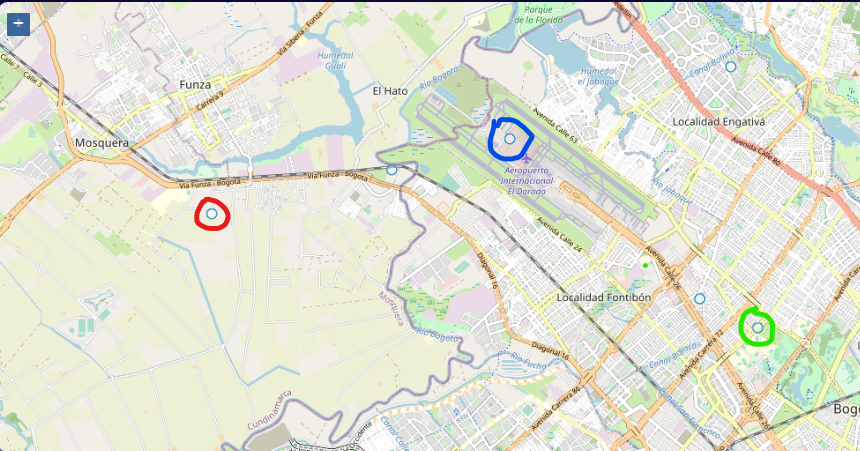

El punto resaltado en azul representa la estación meteorológica del Dorado.

El punto resaltado en rojo representa la estación meteorológica Tibaitatá, la cual se encuentra a 6.64km de la estación del Dorado.

El punto resaltado en verde representa la estación meteorológica del jardín botánico de Bogotá, la cual se encuentra a 6.75km de la estación del Dorado.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Diploma/experimento3.csv")
df
#plt.hist(df.Precipitacion)

,cod_estacion,cod_variable,fecha_observacion,valor_observado
0,21205710,4,2023-01-02 00:00:00,164.333333
1,21205710,4,2023-01-02 01:00:00,168.000000
2,21205710,4,2023-01-02 02:00:00,140.166667
3,21205710,4,2023-01-02 03:00:00,161.333333
4,21205710,4,2023-01-02 04:00:00,152.600000
...,...,...,...,...
1089535,21206990,3,2023-01-06 04:00:00,753.500000
1089536,21206990,3,2023-01-06 05:00:00,753.700000
1089537,21206990,3,2023-01-06 06:00:00,754.300000
1089538,21206990,3,2023-01-06 07:00:00,754.900000


In [ ]:
df['cod_estacion'].value_counts()

21206990    557059
21205791    331288
21205710    201193
Name: cod_estacion, dtype: int64

In [ ]:
#Dorado
def dataset(codigo,H):
  tem = df.loc[(df.cod_estacion == codigo) & (df.cod_variable == 1)]
  tem.rename(columns={'valor_observado':'Temperatura'},inplace=True)
  tem = tem[['fecha_observacion',	'Temperatura']]

  presion = df.loc[(df.cod_estacion == codigo) & (df.cod_variable == 3)]
  presion.rename(columns={'valor_observado':'Presion'},inplace=True)
  presion = presion[['fecha_observacion', 	'Presion']]

  DireViento = df.loc[(df.cod_estacion == codigo) & (df.cod_variable == 4)]
  DireViento.rename(columns={'valor_observado':'DireViento'},inplace=True)
  DireViento = DireViento[['fecha_observacion', 	 'DireViento']]

  VeloViento = df.loc[(df.cod_estacion == codigo) & (df.cod_variable == 5)]
  VeloViento.rename(columns={'valor_observado':'VeloViento'},inplace=True)
  VeloViento = VeloViento[['fecha_observacion', 	 'VeloViento']]

  Precipitacion = df.loc[(df.cod_estacion == codigo) & (df.cod_variable == 2)]
  Precipitacion.rename(columns={'valor_observado':'Precipitacion'},inplace=True)
  Precipitacion = Precipitacion[['fecha_observacion', 	 'Precipitacion']]

  tmp0 = pd.merge(tem, presion, on=['fecha_observacion'],how="outer")
  tmp1 = pd.merge(tmp0, DireViento, on=['fecha_observacion'],how="outer")
  tmp2 = pd.merge(tmp1, VeloViento, on=['fecha_observacion'],how="outer")
  tmp3 = pd.merge(tmp2, Precipitacion, on=['fecha_observacion'],how="outer")
  df_dorado = pd.merge(tmp3, H, on=['fecha_observacion'],how="outer")

  df_dorado.rename(columns={'fecha_observacion':'fecha'},inplace=True)
  df_dorado["fecha"] = pd.to_datetime(df_dorado["fecha"])
  df_dorado.set_index('fecha', inplace=True)
  df_dorado.sort_index(inplace=True)

  frec = 'H'
  df_dorado["fecha"]=df_dorado.index
  df_dorado = df_dorado.groupby(pd.Grouper(key='fecha', freq=frec)).mean()
  df_dorado["fecha"]=df_dorado.index
  df_dorado["fecha"] = pd.to_datetime(df_dorado["fecha"])

  #for i in range(0,len(df_dorado)):
  #  if df_dorado['Precipitacion'][i] >= 4:
  #    df_dorado['Precipitacion'][i] = np.nan
#
  #for i in range(0,len(df_dorado)):
  #  if df_dorado['Presion'][i] <= df_dorado['Presion'].quantile(0.015) or df_dorado['Presion'][i] >= df_dorado['Presion'].quantile(0.99):
  #    df_dorado['Presion'][i] = np.nan

  #df_dorado = df_dorado.groupby(pd.Grouper(key='fecha', freq=frec)).mean()
  #df_dorado["fecha"]=df_dorado.index
  #df_dorado["fecha"] = pd.to_datetime(df_dorado["fecha"])

  return df_dorado

In [ ]:
H_dorado = pd.read_csv("/content/drive/MyDrive/Diploma/humedad_dorado.csv")
H_tiba = pd.read_csv("/content/drive/MyDrive/Diploma/humedad_tiba.csv")
H_jardin = pd.read_csv("/content/drive/MyDrive/Diploma/humedad_jardin.csv")

H_dorado.rename(columns={'fecha':'fecha_observacion'},inplace=True)
H_tiba.rename(columns={'fecha':'fecha_observacion'},inplace=True)
H_jardin.rename(columns={'fecha':'fecha_observacion'},inplace=True)

In [ ]:
df_dorado = dataset(21205791,H_dorado)
#df_tiba   = dataset(21206990,H_tiba)
#df_jardin = dataset(21205710,H_jardin)

<ipython-input-8-ffaa93b64988>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem.rename(columns={'valor_observado':'Temperatura'},inplace=True)
<ipython-input-8-ffaa93b64988>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  presion.rename(columns={'valor_observado':'Presion'},inplace=True)
<ipython-input-8-ffaa93b64988>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DireViento.rename(columns={'valor_observado':'DireViento'},inpla

In [ ]:
C_df_dorado =df_dorado.copy()
C_df_tiba   =df_tiba.copy()
C_df_jardin =df_jardin.copy()

In [ ]:
#Esta celda la tengo por si tengo inconvenientes y tengo que cargar la base de datos original, debido a que se demora tanto la celda que corre la
#funcion es mejor cargar las bases de datos desde sus copias
df_dorado = C_df_dorado.copy()
df_tiba   = C_df_tiba.copy()
df_jardin = C_df_jardin.copy()

##Bases de datos crudas de las estaciones

In [ ]:
df_dorado

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,NaN,NaN,142.000000,4.360000,0.0,NaN,2014-08-29 09:00:00
2014-08-29 10:00:00,16.6,755.2,151.000000,5.333333,0.0,NaN,2014-08-29 10:00:00
2014-08-29 11:00:00,17.1,755.0,157.000000,5.366667,0.0,50.0,2014-08-29 11:00:00
2014-08-29 12:00:00,19.3,754.2,162.833333,5.900000,0.0,48.0,2014-08-29 12:00:00
2014-08-29 13:00:00,18.2,753.5,158.333333,6.433333,0.0,48.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,12.7,753.0,16.666667,3.583333,0.0,100.0,2023-01-23 20:00:00
2023-01-23 21:00:00,13.1,753.7,43.000000,3.150000,0.0,100.0,2023-01-23 21:00:00
2023-01-23 22:00:00,13.3,753.9,59.833333,3.950000,0.0,100.0,2023-01-23 22:00:00


In [ ]:
df_tiba

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2005-01-01 03:00:00,11.0,NaN,NaN,NaN,NaN,NaN,2005-01-01 03:00:00
2005-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2005-01-01 04:00:00
2005-01-01 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2005-01-01 05:00:00
2005-01-01 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2005-01-01 06:00:00
2005-01-01 07:00:00,9.3,NaN,NaN,NaN,NaN,NaN,2005-01-01 07:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,13.2,754.1,50.333333,1.816667,0.0,80.0,2023-01-23 20:00:00
2023-01-23 21:00:00,12.7,755.0,104.333333,1.066667,0.0,83.0,2023-01-23 21:00:00
2023-01-23 22:00:00,12.0,755.1,40.000000,1.583333,0.0,86.0,2023-01-23 22:00:00


In [ ]:
df_jardin

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2017-10-09 14:00:00,NaN,NaN,115.600000,1.620000,0.0,NaN,2017-10-09 14:00:00
2017-10-09 15:00:00,12.2,750.5,220.500000,1.166667,0.6,97.0,2017-10-09 15:00:00
2017-10-09 16:00:00,12.3,750.9,247.833333,0.933333,0.0,93.0,2017-10-09 16:00:00
2017-10-09 17:00:00,11.8,751.5,204.333333,0.500000,0.0,95.0,2017-10-09 17:00:00
2017-10-09 18:00:00,11.4,752.0,144.666667,0.366667,0.0,99.0,2017-10-09 18:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,13.7,752.4,89.166667,1.200000,0.0,75.0,2023-01-23 20:00:00
2023-01-23 21:00:00,13.3,753.1,121.500000,0.850000,0.0,78.0,2023-01-23 21:00:00
2023-01-23 22:00:00,12.4,753.3,125.000000,0.683333,0.0,82.0,2023-01-23 22:00:00


In [ ]:
df_dorado.isna().sum()

Temperatura       6105
Presion          10948
DireViento        9327
VeloViento        8912
Precipitacion     5549
Humedad           7433
fecha                0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] <= '2015-12-31 23:00:00	')].isna().sum()

Temperatura       74
Presion          199
DireViento        71
VeloViento        71
Precipitacion     71
Humedad           76
fecha              0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2016-01-01 00:00:00	') & (df_dorado['fecha'] <= '2016-12-31 23:00:00	')].isna().sum()

Temperatura      129
Presion          502
DireViento       123
VeloViento       123
Precipitacion    124
Humedad          129
fecha              0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2017-01-01 09:00:00	') & (df_dorado['fecha'] <= '2017-12-31 23:00:00	')].isna().sum()

Temperatura       284
Presion          1180
DireViento        260
VeloViento        260
Precipitacion     261
Humedad           291
fecha               0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2018-01-01 00:00:00	') & (df_dorado['fecha'] <= '2018-12-31 23:00:00	')].isna().sum()

Temperatura       475
Presion          1048
DireViento       3563
VeloViento       3526
Precipitacion     338
Humedad           543
fecha               0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2019-01-01 00:00:00	') & (df_dorado['fecha'] <= '2019-12-31 23:00:00	')].isna().sum()

Temperatura      365
Presion          822
DireViento       353
VeloViento       310
Precipitacion    440
Humedad          388
fecha              0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2020-01-01 00:00:00	') & (df_dorado['fecha'] <= '2020-12-31 23:00:00	')].isna().sum()

Temperatura       636
Presion          1186
DireViento        589
VeloViento        530
Precipitacion     477
Humedad           692
fecha               0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2021-01-01 00:00:00	') & (df_dorado['fecha'] <= '2021-12-31 23:00:00	')].isna().sum()

Temperatura      1595
Presion          2592
DireViento       1596
VeloViento       1500
Precipitacion    1463
Humedad          1656
fecha               0
dtype: int64

In [ ]:
df_dorado[(df_dorado['fecha'] >= '2022-01-01 00:00:00	') & (df_dorado['fecha'] <= '2022-12-31 23:00:00	')].isna().sum()

Temperatura      2535
Presion          3385
DireViento       2760
VeloViento       2583
Precipitacion    2358
Humedad          3376
fecha               0
dtype: int64

Text(0.5, 1.0, 'Aeropuerto el Dorado')

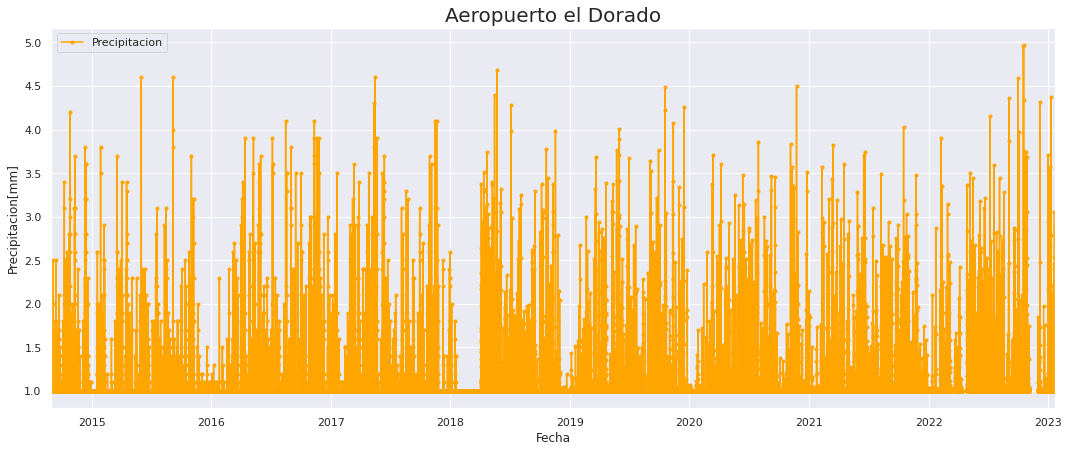

In [ ]:
plt.figure(figsize=(18,7))
(df_dorado['Precipitacion']+1).plot(color='orange', marker='o',ms=3)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Precipitacion[mm]")
plt.title(label="Aeropuerto el Dorado", fontsize=20)

Text(0.5, 1.0, 'Tibaitata')

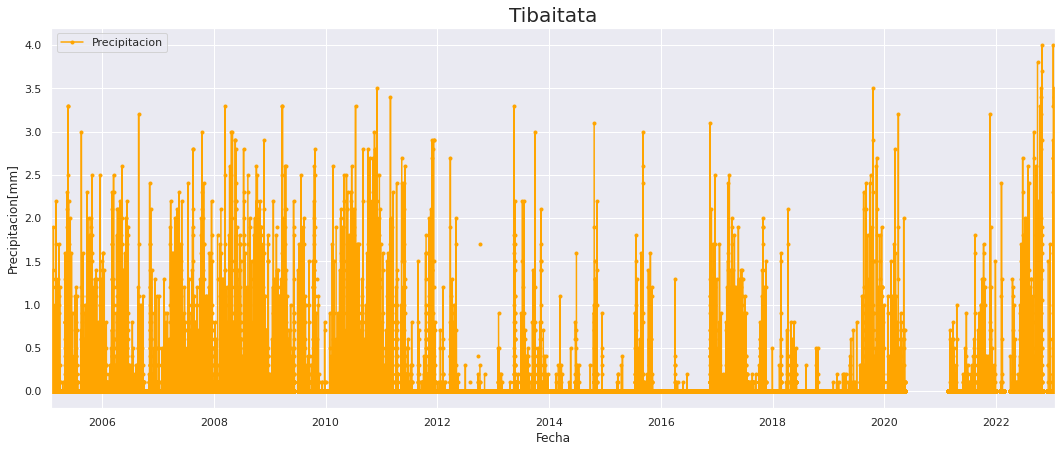

In [ ]:
plt.figure(figsize=(18,7))
df_tiba['Precipitacion'].plot(color='orange', marker='o',ms=3)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Precipitacion[mm]")
plt.title(label="Tibaitata", fontsize=20)

Text(0.5, 1.0, 'Jardín Botanico')

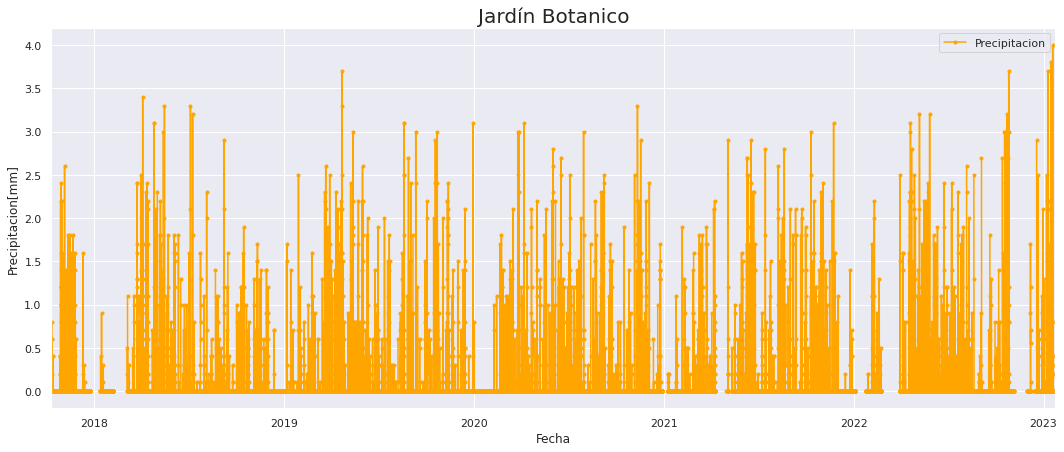

In [ ]:
plt.figure(figsize=(18,7))
df_jardin['Precipitacion'].plot(color='orange', marker='o',ms=3)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Precipitacion[mm]")
plt.title(label="Jardín Botanico", fontsize=20)

##Llenado de la base de datos del dorado con las estaciones del jardín botánico y Tibaitata

In [ ]:
#Recorte de la estación de Tibaitata para que tenga el mismo tamaño de la del dorado
df_tiba = df_tiba[(df_tiba['fecha'] >= '2014-08-29 09:00:00	')]
df_tiba

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,15.3,755.5,142.833333,4.516667,0.0,NaN,2014-08-29 09:00:00
2014-08-29 10:00:00,17.3,755.7,154.166667,5.366667,0.0,NaN,2014-08-29 10:00:00
2014-08-29 11:00:00,18.9,755.5,151.333333,6.383333,0.0,53.0,2014-08-29 11:00:00
2014-08-29 12:00:00,18.6,754.8,142.166667,6.100000,0.0,52.0,2014-08-29 12:00:00
2014-08-29 13:00:00,19.0,754.3,141.166667,5.350000,0.0,53.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,13.2,754.1,50.333333,1.816667,0.0,80.0,2023-01-23 20:00:00
2023-01-23 21:00:00,12.7,755.0,104.333333,1.066667,0.0,83.0,2023-01-23 21:00:00
2023-01-23 22:00:00,12.0,755.1,40.000000,1.583333,0.0,86.0,2023-01-23 22:00:00


In [ ]:
#Recorte de la estación del jardín botánico para que tenga el mismo tamaño de la del dorado

copia = df_tiba[(df_tiba['fecha'] < '2017-10-09 14:00:00')]
copia['Temperatura'] = np.nan
copia['Presion'] = np.nan
copia['DireViento'] = np.nan
copia['VeloViento'] = np.nan
copia['Precipitacion'] = np.nan

df_jardin = pd.concat([copia,df_jardin])

<ipython-input-14-8defc13f6921>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  copia['Temperatura'] = np.nan
<ipython-input-14-8defc13f6921>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  copia['Presion'] = np.nan
<ipython-input-14-8defc13f6921>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

In [ ]:
df_jardin

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-08-29 09:00:00
2014-08-29 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2014-08-29 10:00:00
2014-08-29 11:00:00,NaN,NaN,NaN,NaN,NaN,53.0,2014-08-29 11:00:00
2014-08-29 12:00:00,NaN,NaN,NaN,NaN,NaN,52.0,2014-08-29 12:00:00
2014-08-29 13:00:00,NaN,NaN,NaN,NaN,NaN,53.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,13.7,752.4,89.166667,1.200000,0.0,75.0,2023-01-23 20:00:00
2023-01-23 21:00:00,13.3,753.1,121.500000,0.850000,0.0,78.0,2023-01-23 21:00:00
2023-01-23 22:00:00,12.4,753.3,125.000000,0.683333,0.0,82.0,2023-01-23 22:00:00


In [ ]:
df_tiba

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,15.3,755.5,142.833333,4.516667,0.0,NaN,2014-08-29 09:00:00
2014-08-29 10:00:00,17.3,755.7,154.166667,5.366667,0.0,NaN,2014-08-29 10:00:00
2014-08-29 11:00:00,18.9,755.5,151.333333,6.383333,0.0,53.0,2014-08-29 11:00:00
2014-08-29 12:00:00,18.6,754.8,142.166667,6.100000,0.0,52.0,2014-08-29 12:00:00
2014-08-29 13:00:00,19.0,754.3,141.166667,5.350000,0.0,53.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,13.2,754.1,50.333333,1.816667,0.0,80.0,2023-01-23 20:00:00
2023-01-23 21:00:00,12.7,755.0,104.333333,1.066667,0.0,83.0,2023-01-23 21:00:00
2023-01-23 22:00:00,12.0,755.1,40.000000,1.583333,0.0,86.0,2023-01-23 22:00:00


In [ ]:
df_dorado

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,NaN,NaN,142.000000,4.360000,0.0,NaN,2014-08-29 09:00:00
2014-08-29 10:00:00,16.6,755.2,151.000000,5.333333,0.0,NaN,2014-08-29 10:00:00
2014-08-29 11:00:00,17.1,755.0,157.000000,5.366667,0.0,50.0,2014-08-29 11:00:00
2014-08-29 12:00:00,19.3,754.2,162.833333,5.900000,0.0,48.0,2014-08-29 12:00:00
2014-08-29 13:00:00,18.2,753.5,158.333333,6.433333,0.0,48.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,12.7,753.0,16.666667,3.583333,0.0,100.0,2023-01-23 20:00:00
2023-01-23 21:00:00,13.1,753.7,43.000000,3.150000,0.0,100.0,2023-01-23 21:00:00
2023-01-23 22:00:00,13.3,753.9,59.833333,3.950000,0.0,100.0,2023-01-23 22:00:00


Observemos si tienen todas el mismo tamaño

In [ ]:
df_jardin.shape

(73672, 7)

In [ ]:
df_tiba.shape

(73672, 7)

In [ ]:
df_dorado.shape

(73672, 7)

Para que en el ciclo for me reconozca los valores nulos de los datasets cambiamos de NaN a "nan"

In [ ]:
star = df_dorado.copy()
star['Presion'] = 'nan'
star['Temperatura'] = 'nan'
star['DireViento'] = 'nan'
star['VeloViento'] = 'nan'
star['Precipitacion'] = 'nan'
star['Humedad'] = star['Precipitacion']

In [ ]:
df_tiba.Presion.fillna(star.Presion,inplace=True)
df_tiba.Temperatura.fillna(star.Temperatura,inplace=True)
df_tiba.Precipitacion.fillna(star.Precipitacion,inplace=True)
df_tiba.Humedad.fillna(star.Humedad,inplace=True)
df_tiba.VeloViento.fillna(star.VeloViento,inplace=True)
df_tiba.DireViento.fillna(star.DireViento,inplace=True)

df_jardin.Presion.fillna(star.Presion,inplace=True)
df_jardin.Temperatura.fillna(star.Temperatura,inplace=True)
df_jardin.Precipitacion.fillna(star.Precipitacion,inplace=True)
df_jardin.Humedad.fillna(star.Humedad,inplace=True)
df_jardin.VeloViento.fillna(star.VeloViento,inplace=True)
df_jardin.DireViento.fillna(star.DireViento,inplace=True)

df_dorado.Presion.fillna(star.Presion,inplace=True)
df_dorado.Temperatura.fillna(star.Temperatura,inplace=True)
df_dorado.Precipitacion.fillna(star.Precipitacion,inplace=True)
df_dorado.Humedad.fillna(star.Humedad,inplace=True)
df_dorado.VeloViento.fillna(star.VeloViento,inplace=True)
df_dorado.DireViento.fillna(star.DireViento,inplace=True)
df_dorado

/usr/local/lib/python3.8/dist-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,nan,nan,142.0,4.36,0.0,nan,2014-08-29 09:00:00
2014-08-29 10:00:00,16.6,755.2,151.0,5.333333,0.0,nan,2014-08-29 10:00:00
2014-08-29 11:00:00,17.1,755.0,157.0,5.366667,0.0,50.0,2014-08-29 11:00:00
2014-08-29 12:00:00,19.3,754.2,162.833333,5.9,0.0,48.0,2014-08-29 12:00:00
2014-08-29 13:00:00,18.2,753.5,158.333333,6.433333,0.0,48.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,12.7,753.0,16.666667,3.583333,0.0,100.0,2023-01-23 20:00:00
2023-01-23 21:00:00,13.1,753.7,43.0,3.15,0.0,100.0,2023-01-23 21:00:00
2023-01-23 22:00:00,13.3,753.9,59.833333,3.95,0.0,100.0,2023-01-23 22:00:00


In [ ]:
#Valores nulos antes del llenado de datos con las estaciones
df_dorado.isna().sum()

Temperatura      0
Presion          0
DireViento       0
VeloViento       0
Precipitacion    0
Humedad          0
fecha            0
dtype: int64

Ciclo for donde si se detecta un nan en alguna fila y columna de la base de datos del dorado me lo reemplace por el valor detectado en esa fecha y hora por el promedio del valor obsevado en las estaciones de tibaitata y el jardín botánico, si precisamente en esa fecha y hora también se encuentra un nan en alguna de las estaciones se toma el valor de la estación que tenga el valor, si es todas las estaciones se encuentra un nan, se deja el valor en NaN

In [ ]:
df_llenado = df_dorado.copy()
df4 = df_dorado.copy()
k=0
for j in df_tiba.columns:
  a = df_tiba[j]
  b = df_jardin[j]
  #c = df_llenado[j]
  for i in range(0,len(a)):
    if df4[j][i] == "nan":
      if a[i] != "nan" and b[i] != "nan":
        df_llenado[j][i] = (a[i]+b[i])/2
      if a[i] == "nan" and b[i] != "nan":
        df_llenado[j][i] = b[i]
      if a[i] != "nan" and b[i] == "nan":
        df_llenado[j][i] = a[i]
      if a[i] == "nan" and b[i] == "nan":
        df_llenado[j][i] = np.nan

<ipython-input-24-5788346d8d16>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_llenado[j][i] = a[i]
<ipython-input-24-5788346d8d16>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_llenado[j][i] = np.nan
<ipython-input-24-5788346d8d16>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_llenado[j][i] = (a[i]+b[i])/2
<ipython-input-24-5788346d8d16>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [ ]:
#Valores nulos después del llenado de datos con las estaciones
df_llenado.isna().sum()

Temperatura      2596
Presion          3905
DireViento       3069
VeloViento       2962
Precipitacion    2497
Humedad          2638
fecha               0
dtype: int64

In [ ]:
df_llenado

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,fecha
fecha,,,,,,,
2014-08-29 09:00:00,15.3,755.5,142.0,4.36,0.0,NaN,2014-08-29 09:00:00
2014-08-29 10:00:00,16.6,755.2,151.0,5.333333,0.0,NaN,2014-08-29 10:00:00
2014-08-29 11:00:00,17.1,755.0,157.0,5.366667,0.0,50.0,2014-08-29 11:00:00
2014-08-29 12:00:00,19.3,754.2,162.833333,5.9,0.0,48.0,2014-08-29 12:00:00
2014-08-29 13:00:00,18.2,753.5,158.333333,6.433333,0.0,48.0,2014-08-29 13:00:00
...,...,...,...,...,...,...,...
2023-01-23 20:00:00,12.7,753.0,16.666667,3.583333,0.0,100.0,2023-01-23 20:00:00
2023-01-23 21:00:00,13.1,753.7,43.0,3.15,0.0,100.0,2023-01-23 21:00:00
2023-01-23 22:00:00,13.3,753.9,59.833333,3.95,0.0,100.0,2023-01-23 22:00:00


Text(0.5, 1.0, 'Precipitacion: Aeropuerto el Dorado')

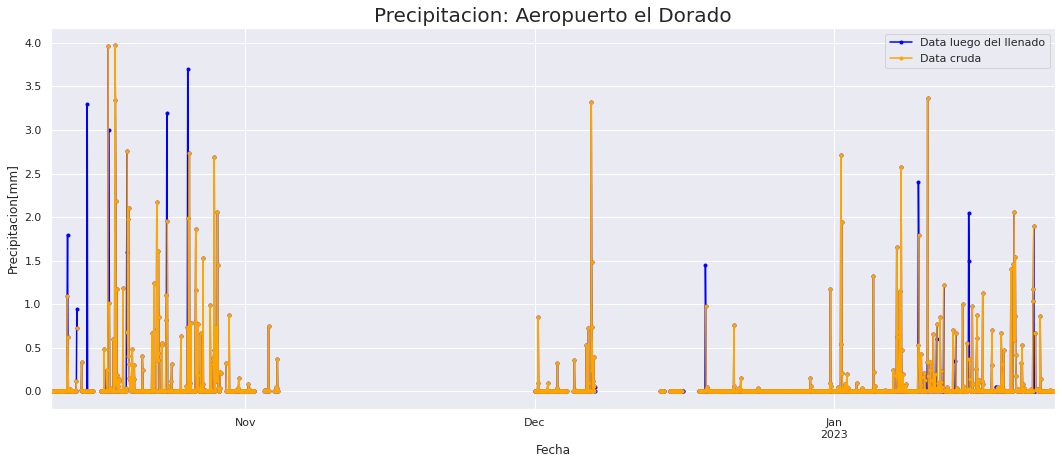

In [ ]:
plt.figure(figsize=(18,7))
df_llenado['Precipitacion'][-2500:].plot(color='blue', marker='o',ms=3,label='Data luego del llenado')
C_df_dorado['Precipitacion'][-2500:].plot(color='orange', marker='o',ms=3, label='Data cruda')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Precipitacion[mm]")
plt.title(label="Precipitacion: Aeropuerto el Dorado", fontsize=20)

Text(0.5, 1.0, 'Temperatura: Aeropuerto el Dorado')

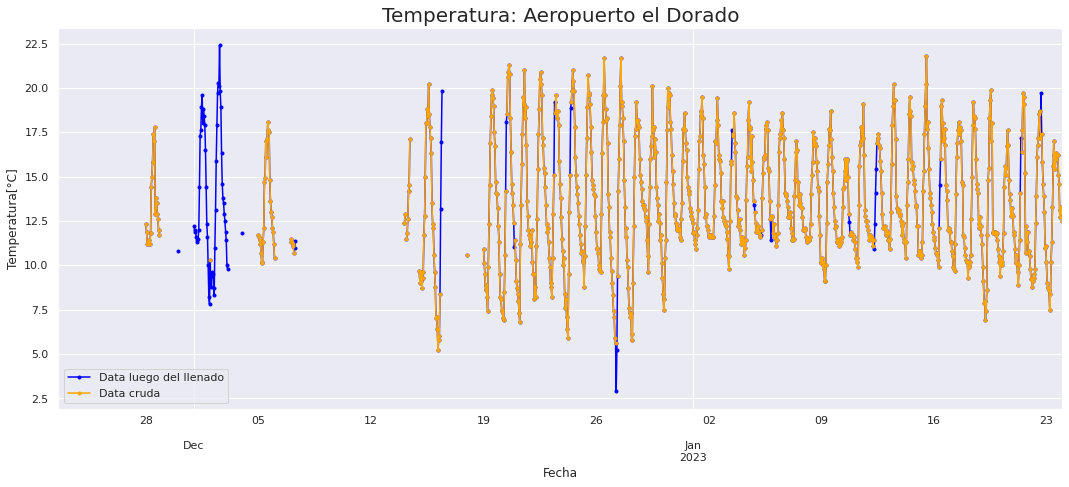

In [ ]:
plt.figure(figsize=(18,7))
df_llenado['Temperatura'][-1500:].plot(color='blue', marker='o',ms=3, label='Data luego del llenado')
C_df_dorado['Temperatura'][-1500:].plot(color='orange', marker='o',ms=3, label='Data cruda')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Temperatura[°C]")
plt.title(label="Temperatura: Aeropuerto el Dorado", fontsize=20)

Text(0.5, 1.0, 'Presion: Aeropuerto el Dorado')

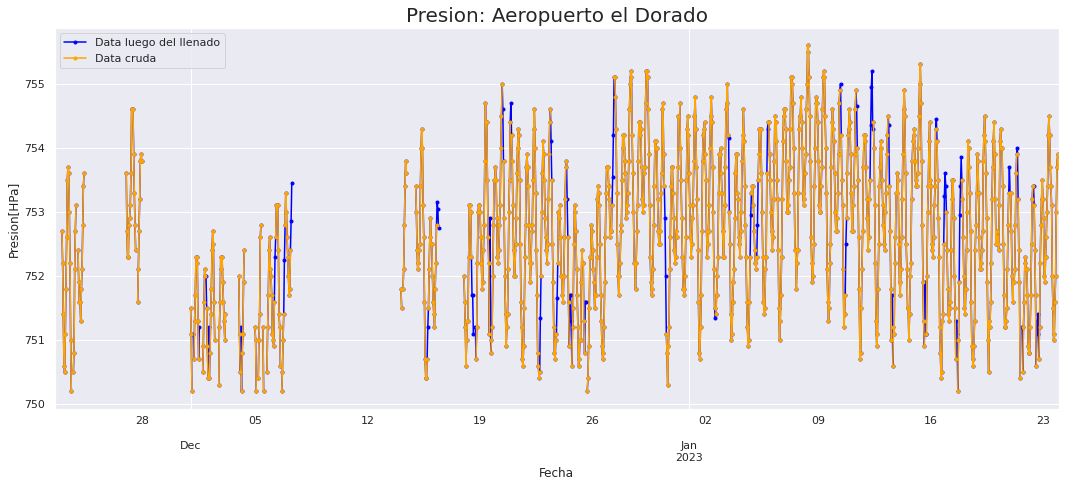

In [ ]:
plt.figure(figsize=(18,7))
df_llenado['Presion'][-1500:].plot(color='blue', marker='o',ms=3,label='Data luego del llenado')
C_df_dorado['Presion'][-1500:].plot(color='orange', marker='o',ms=3,label='Data cruda')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Presion[HPa]")
plt.title(label="Presion: Aeropuerto el Dorado", fontsize=20)

Text(0.5, 1.0, 'Velocidad del Viento: Aeropuerto el Dorado')

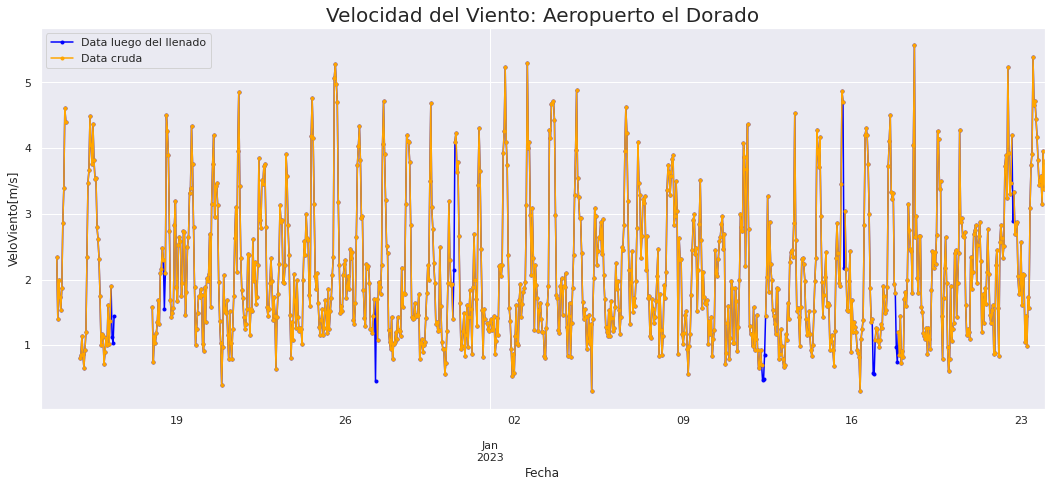

In [ ]:
plt.figure(figsize=(18,7))
df_llenado['VeloViento'][-1000:].plot(color='blue', marker='o',ms=3,label='Data luego del llenado')
C_df_dorado['VeloViento'][-1000:].plot(color='orange', marker='o',ms=3,label='Data cruda')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("VeloViento[m/s]")
plt.title(label="Velocidad del Viento: Aeropuerto el Dorado", fontsize=20)

Text(0.5, 1.0, 'Direccion del Viento: Aeropuerto el Dorado')

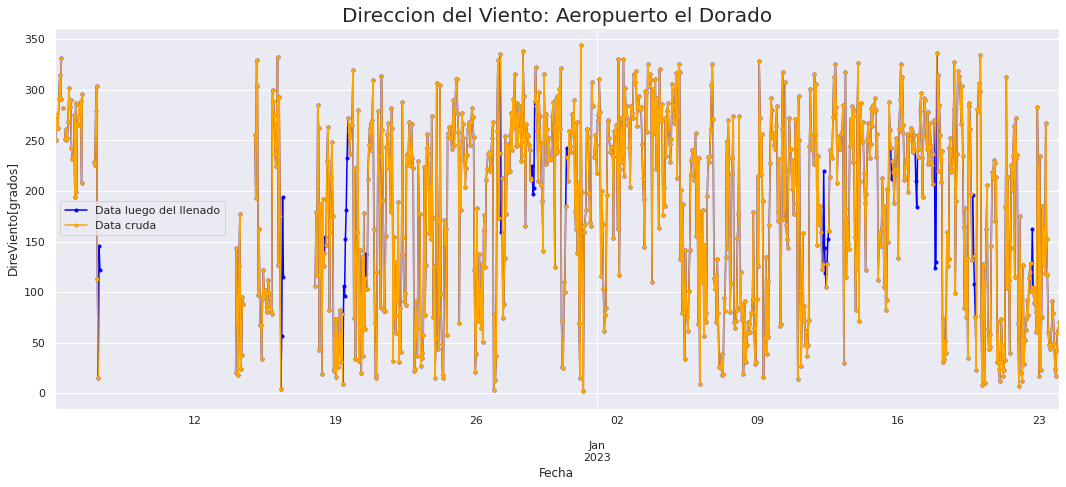

In [ ]:
plt.figure(figsize=(18,7))
df_llenado['DireViento'][-1200:].plot(color='blue', marker='o',ms=3,label='Data luego del llenado')
C_df_dorado['DireViento'][-1200:].plot(color='orange', marker='o',ms=3,label='Data cruda')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("DireViento[grados]")
plt.title(label="Direccion del Viento: Aeropuerto el Dorado", fontsize=20)

Text(0.5, 1.0, 'Humedad: Aeropuerto el Dorado')

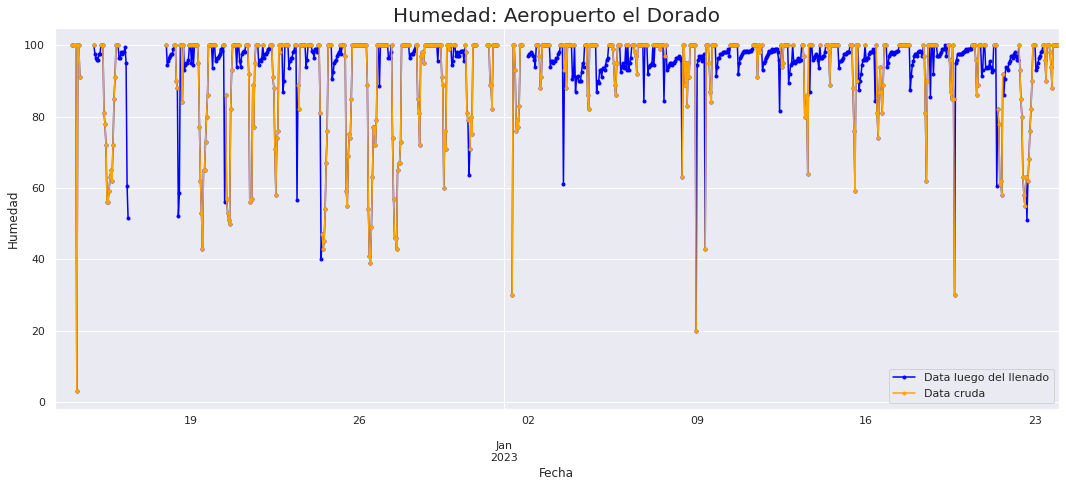

In [ ]:
plt.figure(figsize=(18,7))
df_llenado['Humedad'][-1000:].plot(color='blue', marker='o',ms=3,label='Data luego del llenado')
C_df_dorado['Humedad'][-1000:].plot(color='orange', marker='o',ms=3,label='Data cruda')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Humedad")
plt.title(label="Humedad: Aeropuerto el Dorado", fontsize=20)

In [ ]:
df_f1 =df_dorado[(df_dorado['fecha'] >= '2015-04-01 00:00:00	') & (df_dorado['fecha'] <= '2016-06-25 23:00:00	')]
df_f2 =df_dorado[(df_dorado['fecha'] >= '2015-04-01 00:00:00	') & (df_dorado['fecha'] <= '2016-06-25 23:00:00	')]

In [ ]:
df_f1.isna().sum()

Temperatura      0
Presion          0
DireViento       0
VeloViento       0
Precipitacion    0
Humedad          0
fecha            0
dtype: int64

In [ ]:
df_f1.shape

(10848, 7)

# Valores Faltantes e Interpolación

En este punto haremos uso de una API de python llamada prophet, más información de este: https://facebook.github.io/prophet/docs/quick_start.html

In [ ]:
#USING PROPHET TO PREDICT BEHAVIOR
#df_ph = df_f1[['Tiempo Sistema',df_f1["fecha"]]]

In [ ]:
!pip install neuralprophet

from neuralprophet import NeuralProphet

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
forecast_horizon = 0 #days to forcast
frec = 'H'

m = NeuralProphet()

df_ph = df_f1.copy()
df_ph = df_ph.rename(columns={'fecha': 'ds', 'Temperatura': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
df_ph = df_ph[["ds","y"]]
m.fit(df_ph,freq = frec, epochs =200)
#future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(df_ph)
fcst1= fcst[['ds', 'yhat1']]
fcst1 = fcst1.rename(columns={'ds':'fecha', 'yhat1':'Temperatura'})
fcst1['fecha'] = pd.to_datetime(fcst1['fecha'])
df_f = fcst1.groupby(pd.Grouper(key='fecha')).mean()

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.991% of the data.
INFO:NP.df_utils:Major frequency H corresponds to 99.991% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO:NP.config:Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling yearly seasonality. Run NeuralProphet with yearly_seasonality=True to override this.
INFO:NP.utils:Disabling yearly seasonality. Run NeuralProphet with yearly_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 64
INFO:NP.config:Auto-set batch_size

TypeError: ignored

In [ ]:
forecast_horizon = 0 #days to forcast
frec = 'H'

df_ph = df_f1
df_ph = df_ph.rename(columns={'fecha': 'ds', 'Temperatura': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
m = Prophet(changepoint_prior_scale=0.01).fit(df_ph)
future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(future)
#fcstT = fcst
fcst1= fcst[['ds', 'yhat']]

fcst1 = fcst1.rename(columns={'ds':'fecha', 'yhat':'Temperatura'})
fcst1['fecha'] = pd.to_datetime(fcst1['fecha'])
df_f = fcst1.groupby(pd.Grouper(key='fecha')).mean()

df_ph = df_f1
df_ph = df_ph.rename(columns={'fecha': 'ds', 'Presion': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
m = Prophet(changepoint_prior_scale=0.01).fit(df_ph)
future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(future)
#fcstP = fcst
fcst1= fcst[['ds', 'yhat']]

df_f['Presion'] = np.array(fcst1['yhat'])

df_ph = df_f1
df_ph = df_ph.rename(columns={'fecha': 'ds', 'Humedad': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
m = Prophet(changepoint_prior_scale=0.01).fit(df_ph)
future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(future)
#fcstH = fcst
fcst1= fcst[['ds', 'yhat']]

df_f['Humedad'] = np.array(fcst1['yhat'])

df_ph = df_f1
df_ph = df_ph.rename(columns={'fecha': 'ds', 'VeloViento': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
m = Prophet(changepoint_prior_scale=0.01).fit(df_ph)
future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(future)
#fcstVel = fcst
fcst1= fcst[['ds', 'yhat']]

df_f['VeloViento'] = np.array(fcst1['yhat'])

df_ph = df_f1
df_ph = df_ph.rename(columns={'fecha': 'ds', 'DireViento': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
m = Prophet(changepoint_prior_scale=0.01).fit(df_ph)
future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(future)
#fcstDir = fcst
fcst1= fcst[['ds', 'yhat']]

df_f['DireViento'] = np.array(fcst1['yhat'])

df_ph = df_f1
df_ph = df_ph.rename(columns={'fecha': 'ds', 'Precipitacion': 'y'})
df_ph['ds'] = pd.to_datetime(df_ph['ds'])
m = Prophet(changepoint_prior_scale=0.01).fit(df_ph)
future = m.make_future_dataframe(periods=forecast_horizon, freq=frec)
fcst = m.predict(future)
fcst1= fcst[['ds', 'yhat']]

df_f['Precipitacion'] = np.array(fcst1['yhat'])

df_prophet = df_f.copy()


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpi2tezdwf/2yob9cay.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpi2tezdwf/jemrz8w0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.8/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97707', 'data', 'file=/tmp/tmpi2tezdwf/2yob9cay.json', 'init=/tmp/tmpi2tezdwf/jemrz8w0.json', 'output', 'file=/tmp/tmpi2tezdwf/prophet_model04typxbv/prophet_model-20230216031326.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
03:13:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:13:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tm

In [ ]:
df_prophet

,Temperatura,Presion,Humedad,VeloViento,DireViento,Precipitacion
fecha,,,,,,
2015-04-01 00:00:00,12.832047,753.265475,83.234107,2.129588,87.802306,0.041151
2015-04-01 01:00:00,12.405929,752.829645,85.122347,2.010498,88.678530,0.036661
2015-04-01 02:00:00,12.050709,752.395640,86.383886,1.929915,90.639418,0.030388
2015-04-01 03:00:00,11.678472,752.137968,87.310166,1.920761,90.267935,0.026928
2015-04-01 04:00:00,11.304583,752.168882,88.260974,1.977946,84.737115,0.028365
...,...,...,...,...,...,...
2016-06-25 19:00:00,14.925681,753.899781,75.958106,2.223777,161.624719,0.070441
2016-06-25 20:00:00,14.230267,754.696138,78.899929,1.973840,149.788084,0.070070
2016-06-25 21:00:00,13.760358,755.303901,80.610830,1.872575,138.568066,0.071067


In [ ]:
df_f1['Humedad'].describe()

count    8692.000000
mean       72.374482
std        14.889699
min        26.000000
25%        60.000000
50%        74.000000
75%        85.000000
max        98.000000
Name: Humedad, dtype: float64

In [ ]:
#debido a que la humedad no puede aumentar de 100, valores mayores a él en el ajuste prophet serán tomados como iguales a 100
for i in range(0,len(df_prophet['Humedad'])):
    if df_prophet['Humedad'][i] > 100:
        df_prophet['Humedad'][i] = 100

###Rellenamos los valores nulos en el dataset con los predichos por prophet

In [ ]:
df_f1.Presion.fillna(df_prophet.Presion,inplace=True)
df_f1.Temperatura.fillna(df_prophet.Temperatura,inplace=True)
df_f1.Precipitacion.fillna(0,inplace=True)
df_f1.Humedad.fillna(df_prophet.Humedad,inplace=True)
df_f1.VeloViento.fillna(df_prophet.VeloViento,inplace=True)
df_f1.DireViento.fillna(df_prophet.DireViento,inplace=True)

df_limpio = df_f1.copy()

#df_f1 = pd.concat([df_f1, df_prophet.iloc[-forecast_horizon:]])
#df_f = df_f1.copy()

/usr/local/lib/python3.8/dist-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [ ]:
df_limpio.isna().sum()

Temperatura      0
Presion          0
DireViento       0
VeloViento       0
Precipitacion    0
Humedad          0
fecha            0
dtype: int64

##Presión ajustada

Text(0.5, 1.0, 'Ajuste de la Presion')

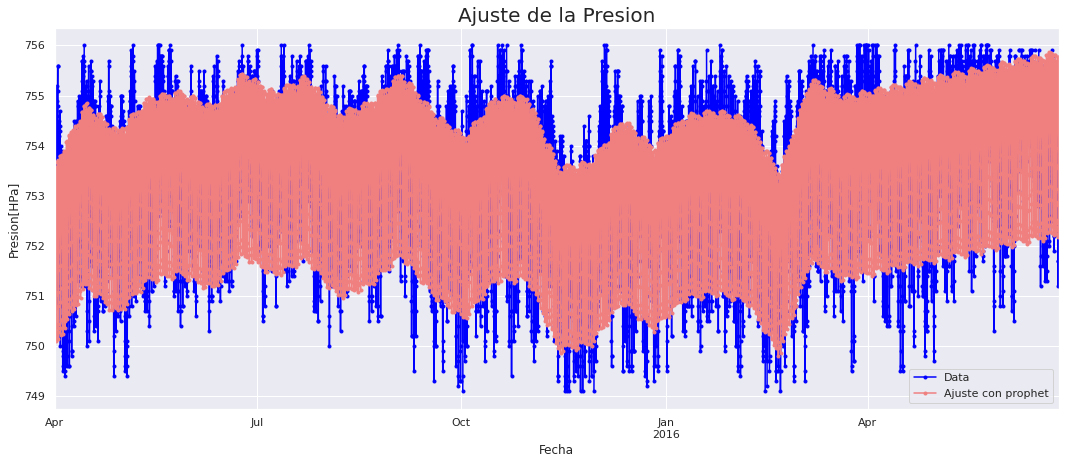

In [ ]:
plt.figure(figsize=(18,7))
#df_prophet['Presion'].plot(color='red', marker='o', linestyle='dotted',lw=0)
#df_llenado['Presion'].plot(color ='blue', marker='o', label="Dataset crudo",lw=1.5)
#df_prophet['Presion'].plot(color='lightcoral', marker='o', ms=3, label = "Ajuste con Prophet")
df_f2['Presion'].plot(color='blue', marker='o',ms=3,label='Data')
df_prophet['Presion'].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Presion[HPa]")
plt.title("Ajuste de la Presion", fontsize=20)

Text(0.5, 1.0, 'Presion: Aeropuerto el Dorado')

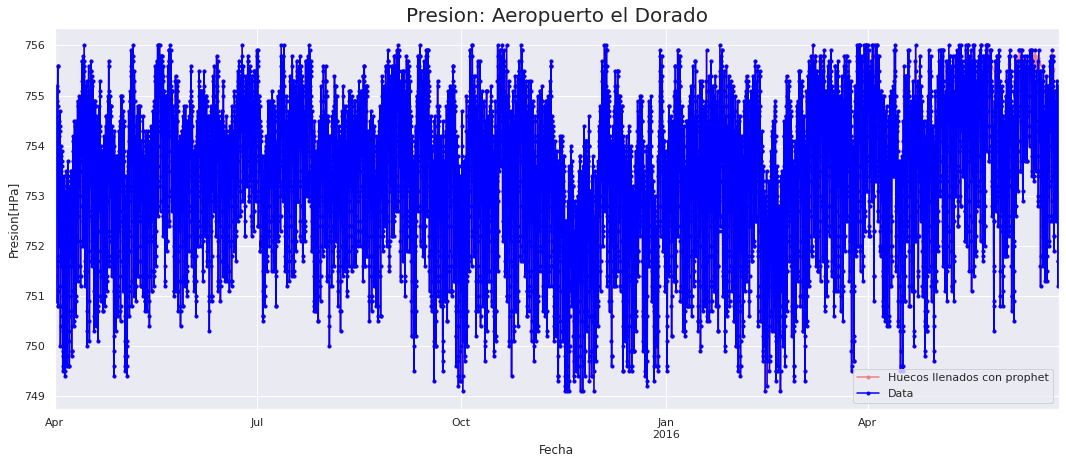

In [ ]:
plt.figure(figsize=(18,7))
df_limpio['Presion'].plot(color='lightcoral', marker='o',ms=3,label='Huecos llenados con prophet')
df_f2['Presion'].plot(color='blue', marker='o',ms=3,label='Data')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Presion[HPa]")
plt.title(label="Presion: Aeropuerto el Dorado", fontsize=20)

##Temperatura ajustada

Text(0.5, 1.0, 'Ajuste de la Temperatura')

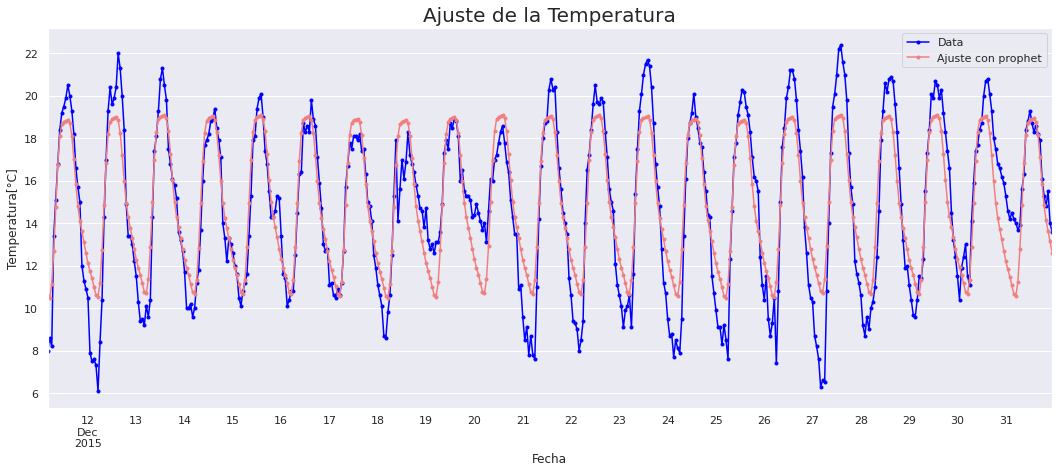

In [ ]:
plt.figure(figsize=(18,7))
df_f2['Temperatura'][-500:].plot(color='blue', marker='o',ms=3,label='Data')
df_prophet['Temperatura'][-500:].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Temperatura[°C]")
plt.title(label="Ajuste de la Temperatura", fontsize=20)

Text(0.5, 1.0, 'Temperatura: Aeropuerto el Dorado')

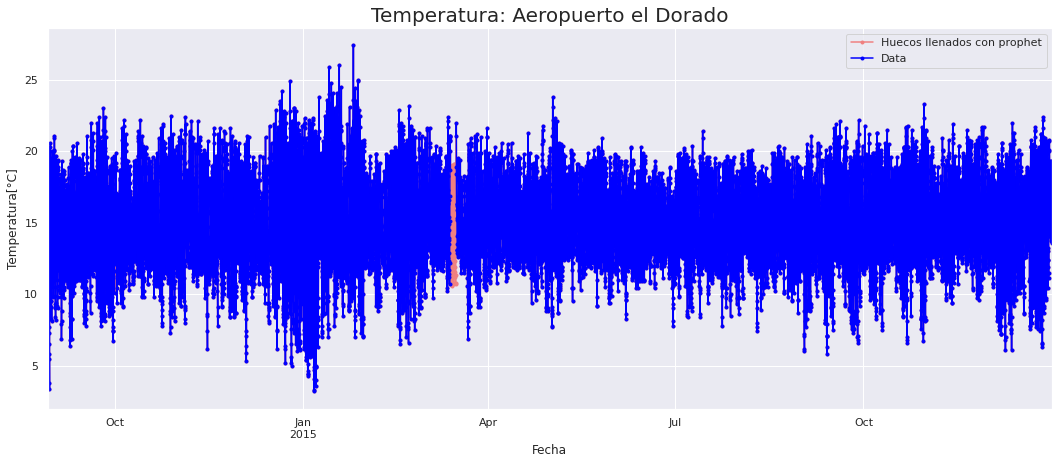

In [ ]:
plt.figure(figsize=(18,7))
df_limpio['Temperatura'].plot(color='lightcoral', marker='o',ms=3,label='Huecos llenados con prophet')
df_f2['Temperatura'].plot(color='blue', marker='o',ms=3,label='Data')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Temperatura[°C]")
plt.title(label="Temperatura: Aeropuerto el Dorado", fontsize=20)

##Velocidad del viento ajustada

Text(0.5, 1.0, 'Ajuste de la Velocidad del Viento')

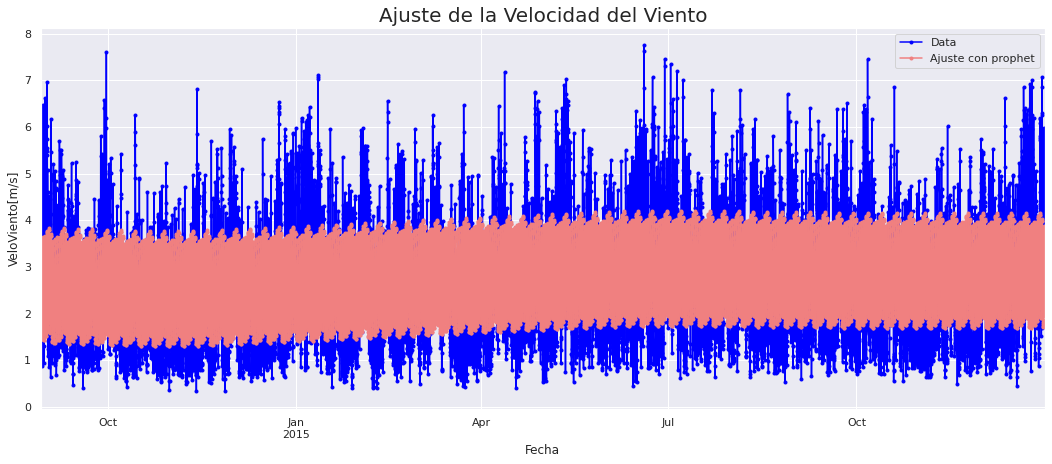

In [ ]:
plt.figure(figsize=(18,7))
df_f2['VeloViento'].plot(color='blue', marker='o',ms=3,label='Data')
df_prophet['VeloViento'].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("VeloViento[m/s]")
plt.title(label="Ajuste de la Velocidad del Viento", fontsize=20)

Text(0.5, 1.0, 'Velocidad del Viento: Aeropuerto el Dorado')

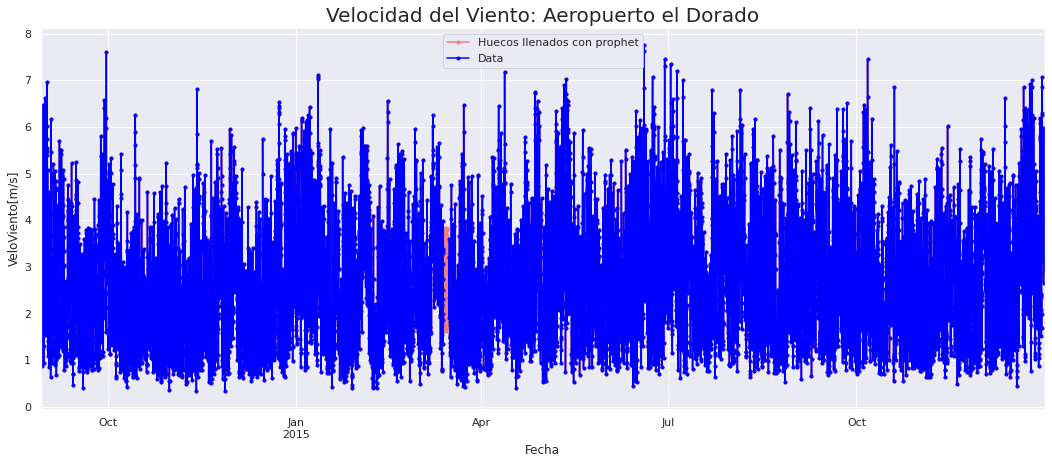

In [ ]:
plt.figure(figsize=(18,7))
df_limpio['VeloViento'].plot(color='lightcoral', marker='o',ms=3,label='Huecos llenados con prophet')
df_f2['VeloViento'].plot(color='blue', marker='o',ms=3,label='Data')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("VeloViento[m/s]")
plt.title(label="Velocidad del Viento: Aeropuerto el Dorado", fontsize=20)

##Dirección del viento ajustada

Text(0.5, 1.0, 'Ajuste de la dirección del Viento')

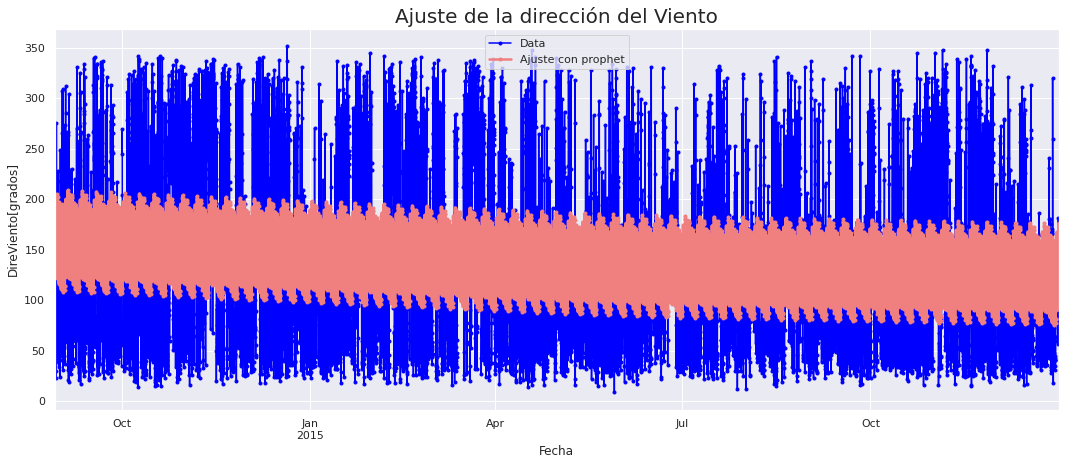

In [ ]:
plt.figure(figsize=(18,7))
df_f2['DireViento'].plot(color='blue', marker='o',ms=3,label='Data')
df_prophet['DireViento'].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet',lw=2.5)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("DireViento[grados]")
plt.title(label="Ajuste de la dirección del Viento", fontsize=20)

Text(0.5, 1.0, 'Dirección del Viento: Aeropuerto el Dorado')

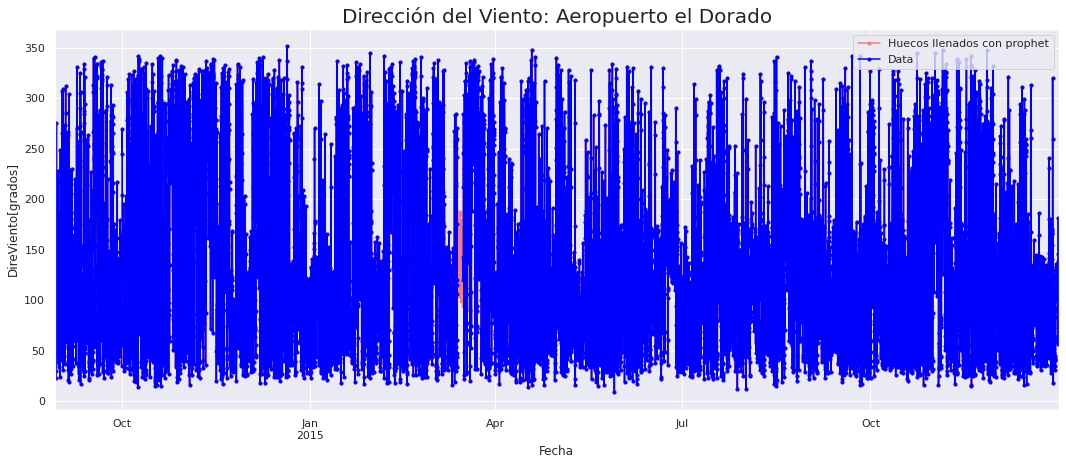

In [ ]:
plt.figure(figsize=(18,7))
df_limpio['DireViento'].plot(color='lightcoral', marker='o',ms=3,label='Huecos llenados con prophet')
df_f2['DireViento'].plot(color='blue', marker='o',ms=3,label='Data')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("DireViento[grados]")
plt.title(label="Dirección del Viento: Aeropuerto el Dorado", fontsize=20)

##Ajuste de la Humedad

Text(0.5, 1.0, 'Ajuste de la Humedad')

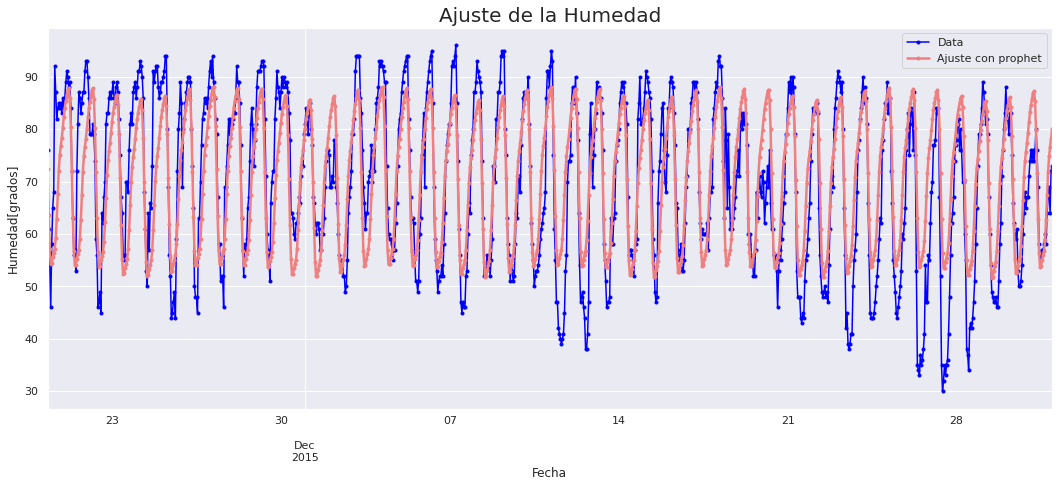

In [ ]:
plt.figure(figsize=(18,7))
df_f2['Humedad'][-1000:].plot(color='blue', marker='o',ms=3  ,label='Data')
df_prophet['Humedad'][-1000:].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet',lw=2.5)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Humedad[grados]")
plt.title(label="Ajuste de la Humedad", fontsize=20)

Text(0.5, 1.0, 'Humedad: Aeropuerto el Dorado')

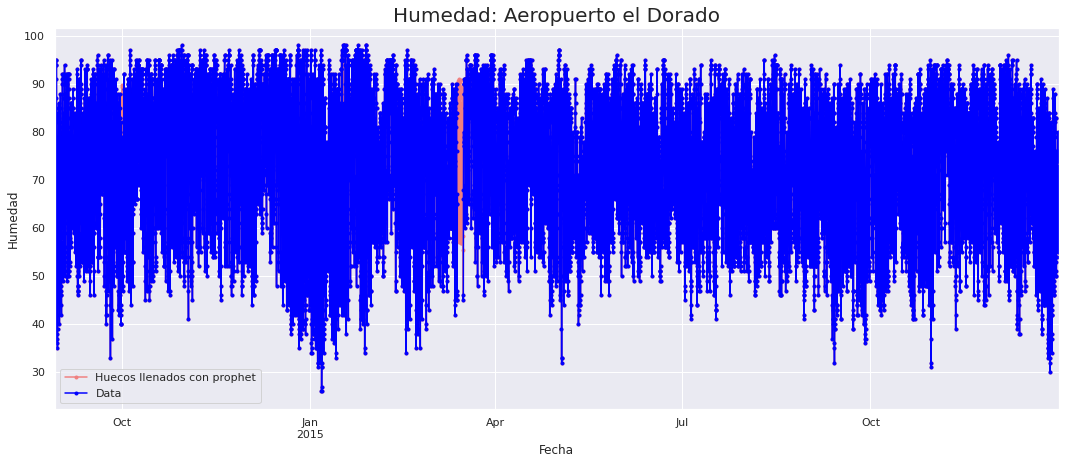

In [ ]:
plt.figure(figsize=(18,7))
df_limpio['Humedad'].plot(color='lightcoral', marker='o',ms=3,label='Huecos llenados con prophet')
df_f2['Humedad'].plot(color='blue', marker='o',ms=3,label='Data')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Humedad")
plt.title(label="Humedad: Aeropuerto el Dorado", fontsize=20)

##Precipitación ajustada
El ajuste de la preciitación no se tuvo en cuenta, por tanto los valores NaN del dataset para esta columna fueron remmplazados por 0

Text(0.5, 1.0, 'Precipitación: Aeropuerto el Dorado')

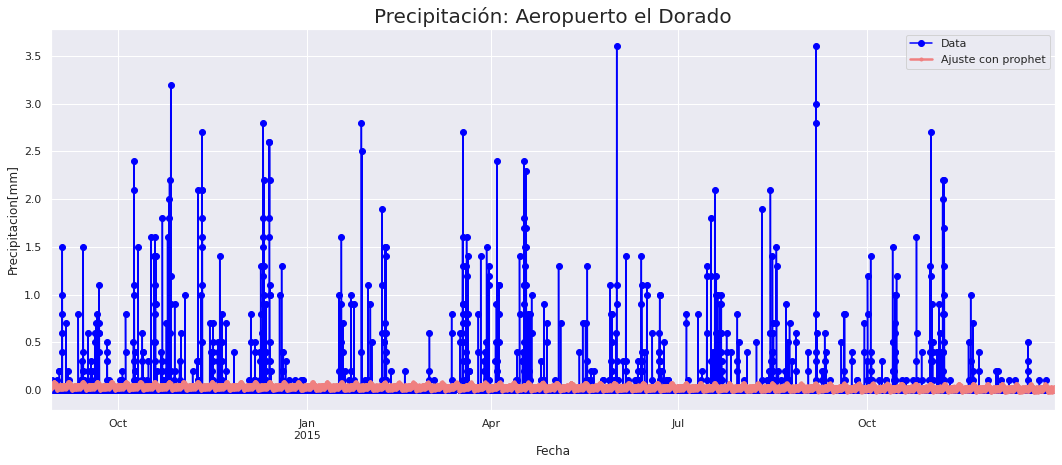

In [ ]:
plt.figure(figsize=(18,7))
df_f2['Precipitacion'].plot(color='blue',title='MaxSpeed', marker='o',label='Data')
df_prophet['Precipitacion'].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet',lw=2.5)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Precipitacion[mm]")
plt.title(label="Precipitación: Aeropuerto el Dorado", fontsize=20)

#**Modelo de Regresión**

Los únicos modelos que corrí teniendo ahora tan alta cantidad de datos fueron el de regresión lineal y el Gradient Boosted trees, este último tarda alrededor de 3 horas.

In [ ]:
frec = '12H'

df_real = df_limpio.groupby(pd.Grouper(freq=frec)).mean()

T_serie2 = df_limpio.groupby(pd.Grouper(freq=frec)).sum()
df_real['Precipitacion'] = T_serie2['Precipitacion']

#df_f1["fecha"]=df_f1.index

Text(0.5, 1.0, 'Precipitación: Aeropuerto el Dorado')

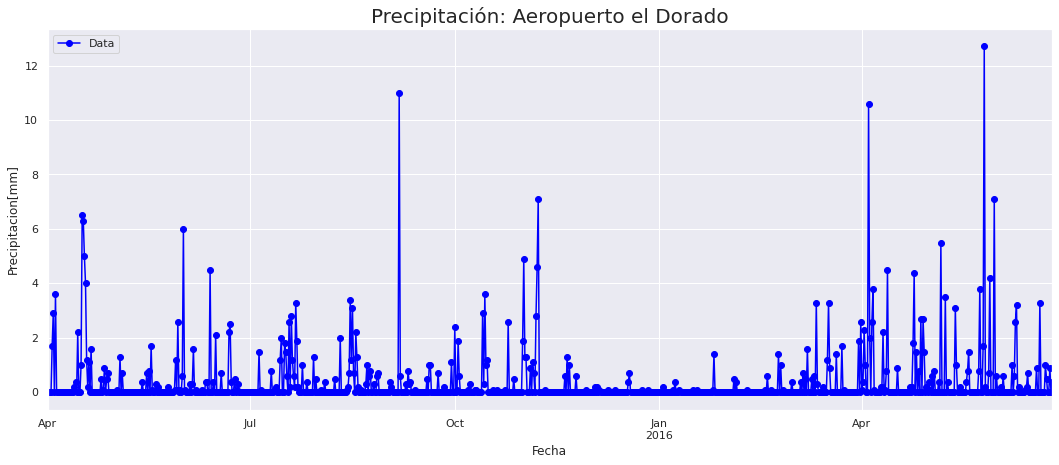

In [ ]:
plt.figure(figsize=(18,7))
df_real['Precipitacion'].plot(color='blue',title='MaxSpeed', marker='o',label='Data')
#df_prophet['Precipitacion'].plot(color='lightcoral', marker='o',ms=3,label='Ajuste con prophet',lw=2.5)
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Precipitacion[mm]")
plt.title(label="Precipitación: Aeropuerto el Dorado", fontsize=20)

In [ ]:
df_real["Precipitacion"] = df_real["Precipitacion"] +1

## Adición de característica: Precipitación pasada
Esta característica representará la precipitación una frecuencia de tiempo antes del valor a ajustar. Por ejemplo, si escogemos una serie de tiempo de las características de 2 días, el 25 de mayo contará con la característica de la precipitación del 23 de mayo. Esto son datos que en la vida real tenemos, si queremos predecir la precipitación del día de hoy contamos la información de la precipitación de ayer, antier, hace 3 días, etc. Estos datos nos ayudará a tener un mejor modelo. Calculemos la importancia de esta característica

In [ ]:
a = []
b = df_real.Precipitacion
for i in range(0,len(b)):
    a.append(b[i-1])
a[0] = np.nan
df_real["PrecipitacionPasada"] = a
df_real.tail()

df_real["PrecipitacionPasada"][0] = 0

## Adición de característica: Día del año
Es sabido que hay periodos del año donde se tienen periodos de lluvia largos, por ende una característica a considerar sería el día del año en que estamos haciendo el cálculo. La característica de día del año nos da la información en qué día de los 365 del año estamos en el momento de hacer la predicción. Calculemos la importancia de esta característica.

In [ ]:
a = []
for col in df_real.index:
  period = pd.Period(col, freq='D')
  a.append(period.day_of_year)
df_real["DiaDelAño"] = a
df_real.tail()

,Temperatura,Presion,DireViento,VeloViento,Precipitacion,Humedad,PrecipitacionPasada,DiaDelAño
fecha,,,,,,,,
2016-06-23 12:00:00,17.300000,753.625000,103.736111,4.043056,1.0,58.916667,1.5,175
2016-06-24 00:00:00,13.058333,754.308333,142.277778,1.934722,1.0,77.250000,1.0,176
2016-06-24 12:00:00,14.666667,753.775000,96.305556,3.297222,1.9,75.000000,1.0,176
2016-06-25 00:00:00,12.308333,754.416667,126.597222,1.300000,1.0,84.500000,1.9,177
2016-06-25 12:00:00,15.941667,753.158333,136.736111,2.798611,1.4,73.666667,1.0,177


In [ ]:
df_real.isna().sum()

Temperatura            0
Presion                0
DireViento             0
VeloViento             0
Precipitacion          0
Humedad                0
PrecipitacionPasada    0
DiaDelAño              0
dtype: int64

# Preparación de los datos

In [ ]:
df_real['fecha'] = df_real.index

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

##Orden de los datos
En este punto elegiremos si queremos nuestros datos revueltos o organizados

In [ ]:
X = df_real[['Temperatura', 'Presion',	'Humedad', 'VeloViento',	'DireViento',"PrecipitacionPasada","DiaDelAño"]]
y = df_real["Precipitacion"]

'''
##  DATOS REVUELTOS ##
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df_predicho = X_test.copy()
'''


##  DATOS ORGANIZADOS ##

a = int(0.85*len(y))
X_train = X.iloc[:a]
y_train = y.iloc[:a]
X_test  = X.iloc[a:]
y_test  = y.iloc[a:]


df_predicho = df_real.copy()

## Normalización de los datos

In [ ]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train  - mean)/std
X_test = (X_test - mean)/std

mean = y_train.mean(axis=0)
std = y_train.std(axis=0)
y_train = (y_train  - mean)/std
y_test = (y_test - mean)/std

# Regresión Lineal

In [ ]:
LR = LinearRegression()
LR.fit(X_train,y_train)

final_results = cross_validate(LR,X_train,y_train,return_train_score=True)

test_scores = final_results['test_score']
train_scores = final_results['train_score']
print("El train score es:",np.mean(train_scores))
print("El test score es:",np.mean(test_scores))

El train score es: 0.17857260268169434
El test score es: -1.0684001628206468


##Predicción

/usr/local/lib/python3.8/dist-packages/pandas/core/indexing.py:1732: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


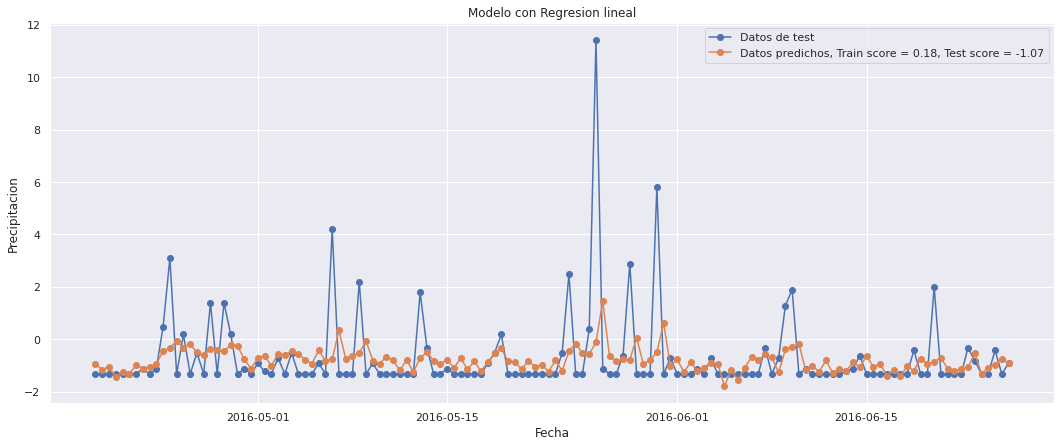

In [ ]:
y_predict = LR.predict(X_test)
df_predicho["Precipitacion"].iloc[a:] = y_predict

plt.figure(figsize=(18,7))
plt.plot(y_test-1,"o-", label="Datos de test")
plt.plot(df_predicho["Precipitacion"].iloc[a:]-1,"o-", label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
#plt.plot(df_f["Precipitacion"].iloc[a:],"o-", label=f"Datos originales")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Regresion lineal")
plt.legend()

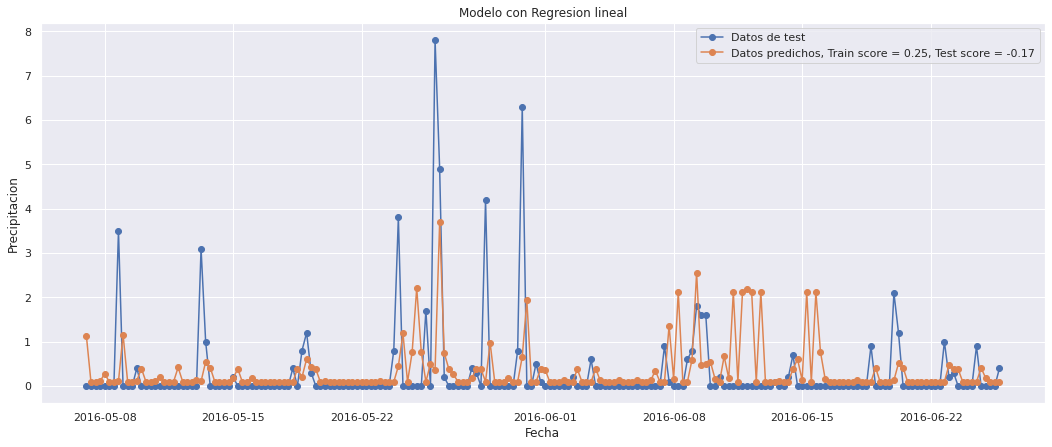

In [ ]:
plt.figure(figsize=(18,7))
plt.plot(y_test[-200:]-1,"o-", label="Datos de test")
plt.plot(df_predicho["Precipitacion"].iloc[-200:]-1,"o-", label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
#plt.plot(df_f["Precipitacion"].iloc[a:],"o-", label=f"Datos originales")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Regresion lineal")
plt.legend()

In [ ]:
c = df_predicho["Precipitacion"].iloc[-410:].values
d = df_f["Precipitacion"].iloc[-410:].values
e = y_test[-410:]
k = np.zeros(len(c))
for i in range(0,len(c)):
  k[i] = (d[i] - c[i])**2

error = ((1/len(c))*np.sum(k))**0.5
error

1.2143033094400373

# **Random forest regression**

##GridSearch para obtener los mejores parámetros

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.simplefilter("ignore")

#X = df_f[['Temperatura', 'Presion','Humedad',	'VeloViento',	'DireViento']]
#X = df_f.drop(['Precipitacion',"latitud",	"longitud"],axis=1)
#y = df_f["Precipitacion"]

rfr = RandomForestRegressor()#n_estimators=240, max_depth = 4)
#results = cross_validate(forest,X,y,cv=5,scoring='r2')

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [10,50, 100,300, 500,700], 'max_depth' : [4,5,6,7,8]}
param_test1 = {'n_estimators':range(20,1001,20), 'max_depth' : range(2,8,1)}

In [ ]:
gsearch2 = GridSearchCV(estimator=rfr,
                        param_grid = param_test1,
                        scoring='r2',
                        cv=5)

In [ ]:
gsearch2.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': range(2, 8),
                         'n_estimators': range(20, 1001, 20)},
             scoring='r2')

In [ ]:
gsearch2.best_estimator_

RandomForestRegressor(max_depth=5, n_estimators=80)

##Resultados finales

In [ ]:
gsearch2.best_score_

-0.9097888412169599

In [ ]:
final_results = cross_validate(gsearch2.best_estimator_,X_train,y_train,return_train_score=True)

test_scores = final_results['test_score']
train_scores = final_results['train_score']
print("El train score es:",np.mean(train_scores))
print("El test score es:",np.mean(test_scores))

El train score es: 0.7278760131642553
El test score es: -1.1727624980377251


In [ ]:
rfr = gsearch2.best_estimator_
#rfr = RandomForestRegressor(n_estimators=60, max_depth = 6)

rfr.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, n_estimators=80)

##Predicción

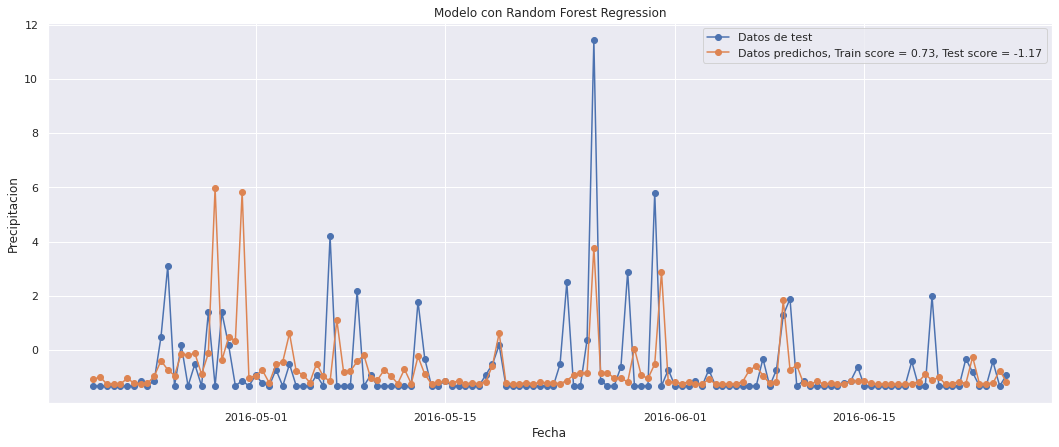

In [ ]:
y_predict = rfr.predict(X_test)
df_predicho["Precipitacion"].iloc[a:] = y_predict

plt.figure(figsize=(18,7))
plt.plot(y_test-1,"o-", label="Datos de test")
plt.plot(df_predicho["Precipitacion"].iloc[a:]-1,"o-", label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Random Forest Regression")
plt.legend()

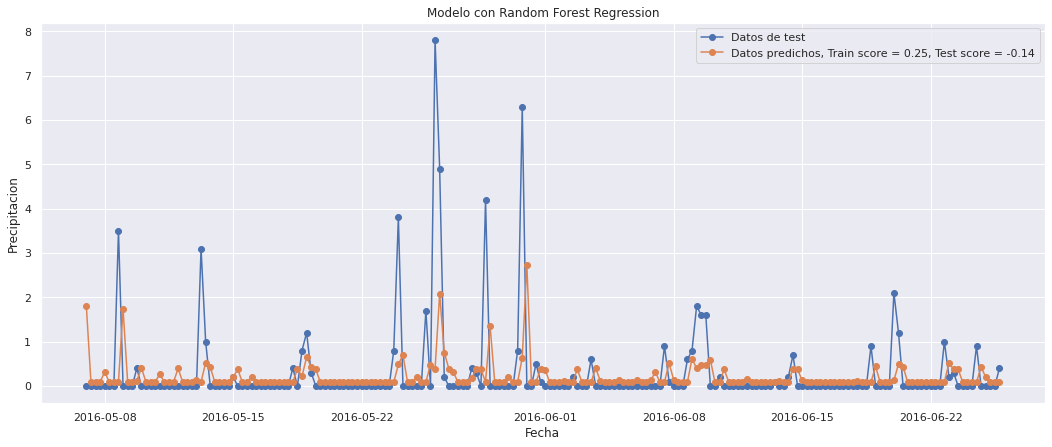

In [ ]:
y_predict = rfr.predict(X_test)
df_predicho["Precipitacion"].iloc[a:] = y_predict

plt.figure(figsize=(18,7))
plt.plot(y_test[-200:]-1,"o-", label="Datos de test")
plt.plot(df_predicho["Precipitacion"].iloc[-200:]-1,"o-", label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Random Forest Regression")
plt.legend()

El valor de R^2 usando random forest es -0.3516388415378209


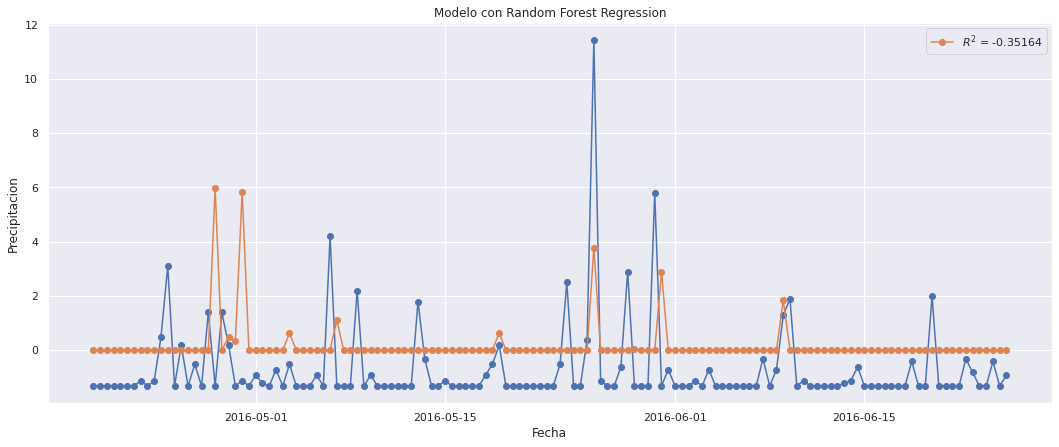

In [ ]:
for i in range(len(df_predicho["Precipitacion"].iloc[a:])):
  if df_predicho["Precipitacion"].iloc[a+i] < 1:
    df_predicho["Precipitacion"].iloc[a+i] = 1

arreglo = np.zeros(len(y_test))
ybarra = np.zeros(len(y_test))
mean = np.mean(y_test)

for i in range(len(y_test)):
  arreglo[i] = (y_test[i] - df_predicho["Precipitacion"].iloc[a+i])**2
  ybarra[i] = (y_test[i] - mean)**2

r2 = 1 - (np.sum(arreglo)/np.sum(ybarra))
print(f"El valor de R^2 usando random forest es {r2}")

plt.figure(figsize=(18,7))
plt.plot(y_test-1,"o-")
plt.plot(df_predicho["Precipitacion"].iloc[a:]-1,"o-", label=f"$R^2$ = {np.round(r2,5)}")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Random Forest Regression")
plt.legend()

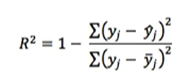

In [ ]:
arreglo = np.zeros(len(y_test))
ybarra = np.zeros(len(y_test))
mean = np.mean(y_test)

for i in range(len(y_test)):
  arreglo[i] = (y_test[i] - df_predicho["Precipitacion"].iloc[a+i])**2
  ybarra[i] = (y_test[i] - mean)**2

r2 = 1 - (np.sum(arreglo)/np.sum(ybarra))
print(f"El valor de R^2 usando random forest es {r2}")

El valor de R^2 usando random forest es -0.3516388415378209


In [ ]:
## PARA DATOS ORGANIZADOS ##

#y_predict = rfr.predict(X_test)
#df_predicho["Precipitacion"].iloc[a:] = y_predict
#
#plt.figure(figsize=(18,7))
#plt.plot(y_test, label="Datos de test")
#plt.plot(df_predicho["Precipitacion"].iloc[a:], label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
#plt.xlabel("Fecha")
#plt.ylabel("Precipitacion")
#plt.title("Modelo con Random Forest Regression")
#plt.legend()


##Importancia de las características

In [ ]:
feature_list = list(X_train.columns)
# Get numerical feature importances
importances = list(rfr.feature_importances_)
# List of tuples with variable and importance
feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
# Print out the feature and importances
[print('Variable: {:20} Importance: {}'.format(*pair)) for pair in feature_importances];

Variable: Humedad              Importance: 0.62
Variable: VeloViento           Importance: 0.08
Variable: DireViento           Importance: 0.07
Variable: Temperatura          Importance: 0.06
Variable: PrecipitacionPasada  Importance: 0.06
Variable: DiaDelAño            Importance: 0.06
Variable: Presion              Importance: 0.04


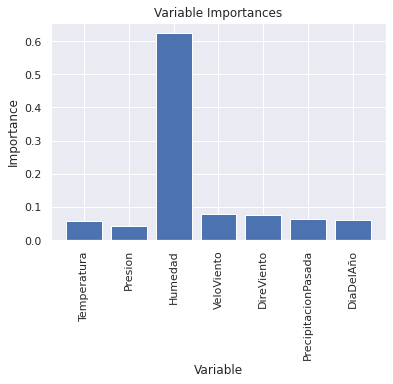

In [ ]:
# Import matplotlib for plotting and use magic command for Jupyter Notebooks
import matplotlib.pyplot as plt
#%matplotlib inline
# Set the style
#plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(importances)))
# Make a bar chart
plt.bar(x_values, importances, orientation = 'vertical')
# Tick labels for x axis
plt.xticks(x_values, feature_list, rotation='vertical')
# Axis labels and title
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');

##Curvas de validación

In [ ]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

In [ ]:
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
    ):
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))
p8_c_t.gjf
    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)

    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")

    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(
        fit_times_mean,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt


IndentationError: ignored

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 14))
title = "Learning Curves (Naive Bayes)"
# Cross validation with 100 iterations to get smoother mean test and train
# score curves, each time with 20% data randomly selected as a validation set.
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=0)
#clf = SVC(gamma = 20.0)
#clf.fit(X_t, y)
plot_learning_curve(rfr, title, X_train, y_train, axes=axes[0:,], ylim=(0, 1.01), cv=cv, n_jobs=4)
plt.show()

# Gradient Boosted Trees

Gradient Boosted representa muchísimos problemas con la data, hay ocasiones donde se puede ver una muy buena regresión, pero hay ocasiones donde el modelo diverge, aún no he encontrado la razón de que pase esto

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate

#ensemble = GradientBoostingRegressor()
#results = cross_validate(ensemble,X_train,y_train,cv=5,scoring='r2')

##Gridsearch para encontrar los mejores parámetros

In [ ]:
from sklearn.model_selection import GridSearchCV

param_test1 = {'n_estimators':range(20,1001,20), 'max_depth' : range(2,9,1)}
estimator = GradientBoostingRegressor(learning_rate=0.1,
                                       min_samples_split=500,
                                       min_samples_leaf=50,
                                       max_features='sqrt',
                                       subsample=0.8,
                                       random_state=10)
gsearch1 = GridSearchCV(estimator,
                        param_grid = param_test1,
                        scoring='r2',
                        cv=5)

In [ ]:
gsearch1.fit(X_train,y_train)

In [ ]:
gsearch1.best_estimator_

In [ ]:
gsearch1.best_score_

In [ ]:
cross_validate(gsearch1.best_estimator_,X_train,y_train)

##Resultados finales

In [ ]:
gsearch1.best_estimator_

In [ ]:
final_results = cross_validate(gsearch1.best_estimator_,X_train,y_train,return_train_score=True)

test_scores = final_results['test_score']
train_scores = final_results['train_score']
print("El train score es:",np.mean(train_scores))
print("El test score es:",np.mean(test_scores))

In [ ]:
estimator = gsearch1.best_estimator_

estimator.fit(X_train,y_train)

#final_results = cross_validate(gsearch2.best_estimator_,X_train,y_train,return_train_score=True)
final_results = cross_validate(estimator,X_train,y_train,return_train_score=True)

test_scores = final_results['test_score']
train_scores = final_results['train_score']
print("El train score es:",np.mean(train_scores))
print("El test score es:",np.mean(test_scores))

In [ ]:
estimator.score(X_test,y_test)

In [ ]:
y_predict = estimator.predict(X_test)
df_predicho["Precipitacion"].iloc[a:] = y_predict

plt.figure(figsize=(18,7))
plt.plot(y_test-1, label="Datos de test")
plt.plot(df_predicho["Precipitacion"].iloc[a:]-1,"o-", label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Gradient Boosted Trees")
plt.legend()

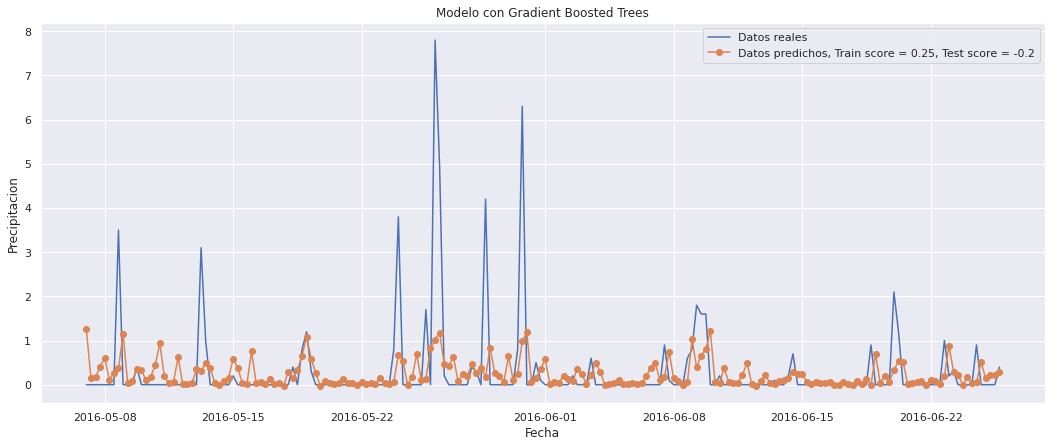

In [ ]:
y_predict = estimator.predict(X_test)
df_predicho["Precipitacion"].iloc[a:] = y_predict

plt.figure(figsize=(18,7))
plt.plot(y_test[-200:]-1, label="Datos reales")
plt.plot(df_predicho["Precipitacion"].iloc[-200:]-1,"o-", label=f"Datos predichos, Train score = {np.round(np.mean(train_scores),2)}, Test score = {np.round(np.mean(test_scores),2)}")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Gradient Boosted Trees")
plt.legend()

In [ ]:
for i in range(len(df_predicho["Precipitacion"].iloc[a:])):
  if df_predicho["Precipitacion"].iloc[a+i] < 1:
    df_predicho["Precipitacion"].iloc[a+i] = 1

y_test
df_predicho["Precipitacion"].iloc[a:]
arreglo = np.zeros(len(y_test))
ybarra = np.zeros(len(y_test))
mean = np.mean(y_test)

for i in range(len(y_test)):
  arreglo[i] = (y_test[i] - df_predicho["Precipitacion"].iloc[a+i])**2
  ybarra[i] = (y_test[i] - mean)**2

r2 = 1 - (np.sum(arreglo)/np.sum(ybarra))

plt.figure(figsize=(18,7))
plt.plot(y_test-1,"o-", label="Datos de test")
plt.plot(df_predicho["Precipitacion"].iloc[a:]-1,"o-", label=f"$R^2$ = {np.round(r2,3)}")
plt.xlabel("Fecha")
plt.ylabel("Precipitacion")
plt.title("Modelo con Random Forest Regression")
plt.legend()

In [ ]:
y_test
df_predicho["Precipitacion"].iloc[a:]
arreglo = np.zeros(len(y_test))
ybarra = np.zeros(len(y_test))
mean = np.mean(y_test)

for i in range(len(y_test)):
  arreglo[i] = (y_test[i] - df_predicho["Precipitacion"].iloc[a+i])**2
  ybarra[i] = (y_test[i] - mean)**2

r2 = 1 - (np.sum(arreglo)/np.sum(ybarra))
print(f"El valor de R^2 usando gradient boosted es {r2}")

##Importancia de las características

In [ ]:
feature_list = list(X_train.columns)
# Get numerical feature importances
importances = list(estimator.feature_importances_)
# List of tuples with variable and importance
feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(feature_list, importances)]
# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
# Print out the feature and importances
[print('Variable: {:20} Importance: {}'.format(*pair)) for pair in feature_importances];

In [ ]:
# Import matplotlib for plotting and use magic command for Jupyter Notebooks
import matplotlib.pyplot as plt
#%matplotlib inline
# Set the style
#plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(importances)))
# Make a bar chart
plt.bar(x_values, importances, orientation = 'vertical')
# Tick labels for x axis
plt.xticks(x_values, feature_list, rotation='vertical')
# Axis labels and title
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');

#Regresión con NN (No lo logré :))

In [ ]:
pip install --no-deps scikeras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from sklearn.model_selection import cross_validate
from scikeras.wrappers import KerasRegressor
from keras.datasets import boston_housing
from keras import models, layers, optimizers

In [ ]:
x1 = pd.DataFrame(X_train)
x2 = pd.DataFrame(X_test)

X1 = pd.concat([x1,x2],axis=0)

y1 = pd.DataFrame(y_train)
y2 = pd.DataFrame(y_test)

Y1 = pd.concat([y1,y2],axis=0)

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
m = ss.fit_transform(X1)
X = pd.DataFrame(m)

n = ss.fit_transform(Y1)
y = pd.DataFrame(n)

In [ ]:
def funcion1():
    model = models.Sequential()
    model.add(layers.Dense(64,activation='relu',input_shape=(13,)))
    model.add(layers.Dense(64,activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse',metrics=['mae'])
    return model

In [ ]:
prob_keras = KerasRegressor(model=funcion1,epochs=10,batch_size=16)

In [ ]:
cross = cross_validate(prob_keras,X,y,cv=7,verbose=2,return_train_score=True,scoring="r2");

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Epoch 1/10
[CV] END .................................................... total time=   0.7s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.7s remaining:    0.0s


Epoch 1/10
[CV] END .................................................... total time=   0.3s
Epoch 1/10
[CV] END .................................................... total time=   0.2s
Epoch 1/10
[CV] END .................................................... total time=   0.2s
Epoch 1/10
[CV] END .................................................... total time=   0.2s
Epoch 1/10
[CV] END .................................................... total time=   0.1s
Epoch 1/10
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    1.8s finished


In [ ]:
pd.DataFrame(cross).mean()

fit_time       0.245553
score_time     0.000000
test_score          NaN
train_score         NaN
dtype: float64